# Navier-Stokes Equations — FEniCSx Demo

Solve the incompressible Navier-Stokes equations on the unit square (lid-driven cavity):

$$\frac{\partial u}{\partial t} + (u \cdot \nabla) u - \nu \Delta u + \nabla p = f$$
$$\nabla \cdot u = 0$$

**Method:** Backward Euler time stepping, Taylor-Hood P2/P1 elements.  
**Problem:** Lid-driven cavity, Re = 100 (ν = 0.01), regularized lid u = (4x(1-x), 0) on top boundary.  
**Linearization:** Convecting velocity taken explicitly: $(u^n \cdot \nabla)u^{n+1}$.  
**Note:** The lid is regularized to zero at the corners to remove the pressure singularity that arises when a discontinuous lid BC meets no-slip walls.

In [ ]:
import os
os.environ['OMP_NUM_THREADS'] = '1'  # force single-threaded MUMPS; prevents non-deterministic factorization errors on Mac

from mpi4py import MPI
import numpy as np
from dolfinx import mesh, fem, default_scalar_type
from dolfinx.fem import functionspace, Function, dirichletbc, locate_dofs_topological
from dolfinx.fem.petsc import apply_lifting, set_bc, create_vector
from dolfinx.mesh import locate_entities_boundary
from ufl import TestFunctions, TrialFunctions, dx, grad, div, inner
import basix.ufl
from petsc4py import PETSc
import dolfinx.fem.petsc as petsc_fem

In [2]:
domain = mesh.create_unit_square(MPI.COMM_WORLD, 32, 32)

P2 = basix.ufl.element("Lagrange", domain.topology.cell_name(), 2,
                        shape=(domain.geometry.dim,))
P1 = basix.ufl.element("Lagrange", domain.topology.cell_name(), 1)
TH = basix.ufl.mixed_element([P2, P1])
W = functionspace(domain, TH)

nu = fem.Constant(domain, default_scalar_type(0.1))
dt = fem.Constant(domain, default_scalar_type(0.01))
T  = 3.0
f  = fem.Constant(domain, (default_scalar_type(0), default_scalar_type(0)))

print(f"Total dofs: {W.dofmap.index_map.size_global * W.dofmap.index_map_bs}")
print(f"Time steps: {int(T / 0.01)}")
print(f"Re = {1.0 / 0.01:.0f}")

Total dofs: 9539
Time steps: 300
Re = 100


In [3]:
def noslip_boundary(x):
    return np.logical_or.reduce([
        np.isclose(x[0], 0),
        np.isclose(x[0], 1),
        np.isclose(x[1], 0)
    ])

def lid_boundary(x):
    return np.isclose(x[1], 1)

V_collapsed, _ = W.sub(0).collapse()

noslip_dofs = locate_dofs_topological(
    (W.sub(0), V_collapsed), domain.topology.dim - 1,
    locate_entities_boundary(domain, domain.topology.dim - 1, noslip_boundary))
u_noslip = Function(V_collapsed)
u_noslip.x.array[:] = 0
bc_noslip = dirichletbc(u_noslip, noslip_dofs, W.sub(0))

lid_dofs = locate_dofs_topological(
    (W.sub(0), V_collapsed), domain.topology.dim - 1,
    locate_entities_boundary(domain, domain.topology.dim - 1, lid_boundary))
u_lid = Function(V_collapsed)
u_lid.interpolate(lambda x: np.vstack([
    4 * x[0] * (1 - x[0]) * np.ones(x.shape[1]),
    np.zeros(x.shape[1])
]))
bc_lid = dirichletbc(u_lid, lid_dofs, W.sub(0))

bcs = [bc_noslip, bc_lid]
print(f"Max lid velocity: {u_lid.x.array.max():.4f}")

Max lid velocity: 1.0000


In [ ]:
from ufl import nabla_grad, dot
from dolfinx.fem import form

wh  = Function(W)
wh0 = Function(W)

V_sub, sub_map = W.sub(0).collapse()  # kept for post-processing only

(u, p) = TrialFunctions(W)
(v, q) = TestFunctions(W)

u_old = wh0.sub(0)

a = (inner(u, v) / dt
     + nu * inner(grad(u), grad(v))
     + inner(dot(nabla_grad(u), u_old), v)
     - p * div(v)
     + div(u) * q) * dx

L = (inner(u_old, v) / dt
     + inner(f, v)) * dx

a_form = form(a)
L_form = form(L)

print("Variational form compiled.")

In [ ]:
A = petsc_fem.create_matrix(a_form)
b = create_vector(W)

solver = PETSc.KSP().create(domain.comm)
solver.setType(PETSc.KSP.Type.PREONLY)
pc = solver.getPC()
pc.setType(PETSc.PC.Type.LU)
pc.setFactorSolverType("mumps")

t = 0.0
n_steps = int(T / 0.01)
max_u = []

u_meas = Function(V_sub)  # pre-allocated; reused for measurement each step

for step in range(n_steps):
    t += 0.01

    wh0.x.array[:] = wh.x.array[:]
    wh0.x.scatter_forward()

    A.zeroEntries()
    petsc_fem.assemble_matrix(A, a_form, bcs=bcs)
    A.assemble()

    with b.localForm() as b_loc:
        b_loc.set(0)
    petsc_fem.assemble_vector(b, L_form)
    apply_lifting(b, [a_form], [bcs])
    b.ghostUpdate(addv=PETSc.InsertMode.ADD, mode=PETSc.ScatterMode.REVERSE)
    set_bc(b, bcs)

    solver.setOperators(A)
    solver.setUp()
    pc.getFactorMatrix().setMumpsCntl(1, 0.1)  # raise pivot threshold; default 0.01 misses near-zero pivot at ~t=0.89
    solver.solve(b, wh.x.petsc_vec)
    wh.x.scatter_forward()

    u_meas.interpolate(wh.sub(0))
    u_arr = u_meas.x.array.reshape(-1, domain.geometry.dim)
    mag = np.linalg.norm(u_arr, axis=1).max()
    max_u.append(mag)

    if (step + 1) % 10 == 0:
        print(f"t = {t:.2f}, max|u| = {mag:.4f}")

print("Time loop complete.")

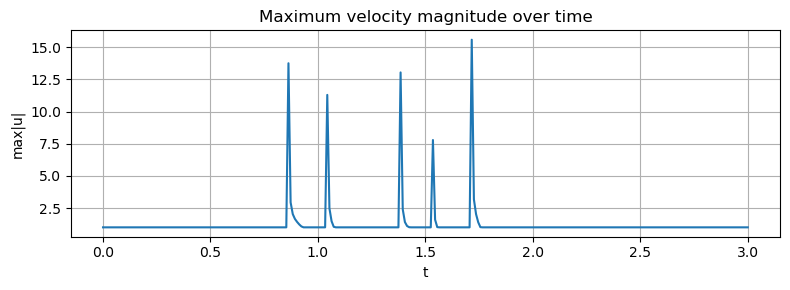

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(np.linspace(0, T, n_steps), max_u)
plt.xlabel("t")
plt.ylabel("max|u|")
plt.title("Maximum velocity magnitude over time")
plt.grid(True)
plt.tight_layout()
plt.show()

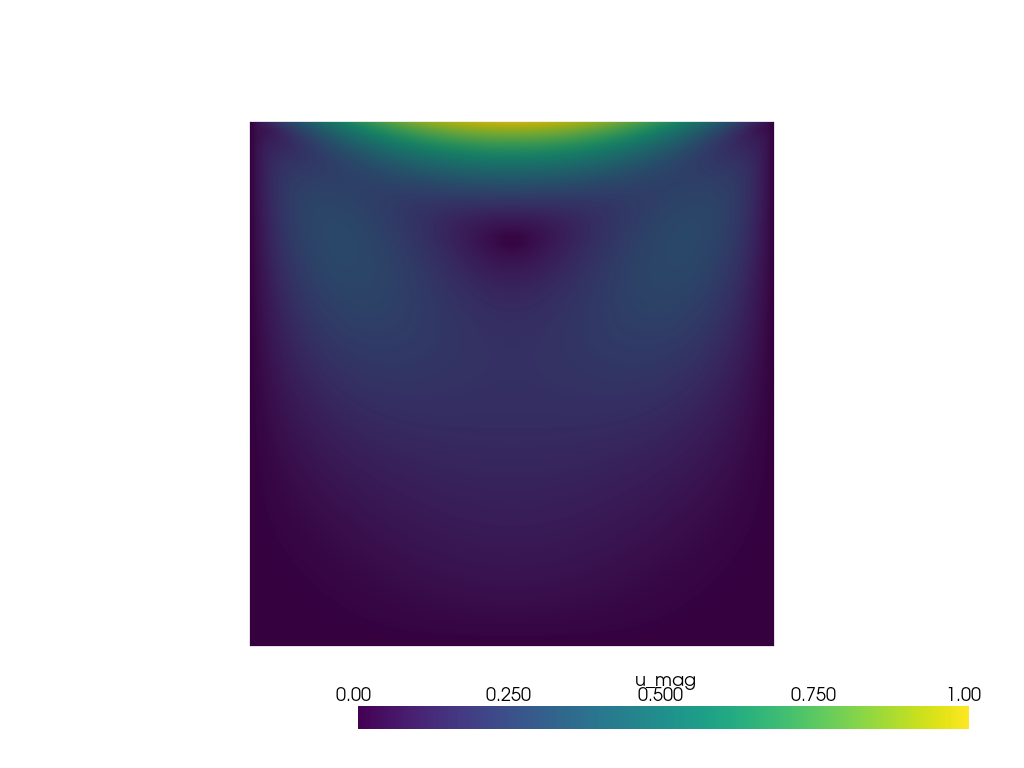

In [7]:
import pyvista as pv
from dolfinx.plot import vtk_mesh

pv.set_jupyter_backend("static")

V_vis, dof_map = W.sub(0).collapse()
u_vis = Function(V_vis)
u_vis.x.array[:] = wh.x.array[dof_map]

topology, cell_types, geometry = vtk_mesh(V_vis)
grid = pv.UnstructuredGrid(topology, cell_types, geometry)

u_array = u_vis.x.array.reshape(-1, domain.geometry.dim)
grid.point_data["u_mag"] = np.linalg.norm(u_array, axis=1)

plotter = pv.Plotter()
plotter.add_mesh(grid, scalars="u_mag", cmap="viridis")
plotter.view_xy()
plotter.show()